### Tracking fires with PACE data
Author: Skye Caplan

Last updated: October 29th, 2025

This notebook uses PACE data to investigate the burn severity of various wildfires. New events can be added in the ```User Input``` section in the cell below. 

In [1]:
# Add parent dir to path for utils access
import sys, os
sys.path.append(os.path.dirname(os.path.abspath('')))

# Import packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
import cartopy.crs as ccrs
import rasterio 
import rioxarray as rio
import cf_xarray
import earthaccess
import seaborn as sns
import glob
import utilities.useful_functions as utils
from rasterio.enums import Resampling
from cartopy.feature import ShapelyFeature 
from cartopy.io.shapereader import Reader 

# Import water mask for plotting and set title
shp = "water_mask/water_mask.shp"
water_mask = ShapelyFeature(Reader(shp).geometries(), crs=ccrs.PlateCarree())

# Define necessary specific fcns not incl'd in utils
def calc_nbr(nir, swir):
    """
    Calculates Normalized Burn Ratio given NIR and SWIR datasets
    Args:
        nir, swir - datasets of NIR and SWIR info
    Returns:
        nbr - NBR dataset
    """
    nbr = ((nir - swir) / (nir + swir))
    nbr = nbr.rename({"rhos":"nbr"})
    return nbr

#################################################################
#                         User Input                            #
#################################################################

# Set up known scenes; (w, s, e, n) as per earthaccess bounding_box
scenes = {"mb":(-102, 53.5, -92, 59), "la":(-120, 33, -116, 35),
          "pgl":(-10,  36.5, -2, 43.9)}
times = {"la":[("2024-12-07", "2024-12-18"),
               ("2025-01-13", "2025-01-15")],
         "pgl":[("2025-07-25", "2025-08-08"),   # aug 8 clear, jul 28 mostly jul 26 and 25
                ("2025-09-16", "2025-09-25")],  # sept 16, 17ish, 25
                 
        }
grans = {"pgl":["*20250808T124711*","*20250726T131718*",
                "*20250916T123802*","*20250925T130313*", 
                "*20250925T125813*"]}
loc = "pgl"

# Plot title 
title = "dNBR, Portugal/Spain Fires (August 2025)"

# Set up vars for specific event
scene = scenes[loc]
time = times[loc]
plot_ext = [scene[0],scene[2],scene[1],scene[3]]

# Times to grab granules from
tspan_pre = time[0]
tspan_post = time[1]

# Processing in the cloud?
in_the_cloud = False

In [3]:
# Set credentials
auth = earthaccess.login(persist=True)

In [15]:
# Grabbing granules
results = []

for gran in grans[loc]:
    res = earthaccess.search_data(
        short_name=["PACE_OCI_L2_SFREFL_NRT", "PACE_OCI_L2_SFREFL"],
        granule_name=gran,
    )
    try:
        display(res[0])
        results.append(res[0])
    except:
        print(gran)
    
#results = earthaccess.search_data(
#    short_name=["PACE_OCI_L2_SFREFL","PACE_OCI_L2_SFREFL_NRT"],
#    temporal=tspan_pre,
#    bounding_box=scene,
#    granule_name=grans[loc],
#    cloud_cover=(0, 75)
#)
#results[-1]

Collection: {'ShortName': 'PACE_OCI_L2_SFREFL_NRT', 'Version': '3.1'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 59.45042, 'Longitude': 11.8863}, {'Latitude': 52.45399, 'Longitude': -30.75128}, {'Latitude': 36.06538, 'Longitude': -18.66977}, {'Latitude': 41.74865, 'Longitude': 11.8502}, {'Latitude': 59.45042, 'Longitude': 11.8863}]}}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2025-08-08T12:52:10Z', 'BeginningDateTime': '2025-08-08T12:47:11Z'}}
Size(MB): 726.5648612976074
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250808T124711.L2.SFREFL.V3_1.NRT.nc']

Collection: {'ShortName': 'PACE_OCI_L2_SFREFL_NRT', 'Version': '3.1'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 44.91541, 'Longitude': 3.15657}, {'Latitude': 39.08424, 'Longitude': -28.83543}, {'Latitude': 21.84383, 'Longitude': -21.25851}, {'Latitude': 27.10223, 'Longitude': 4.77869}, {'Latitude': 44.91541, 'Longitude': 3.15657}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2025-07-26T13:17:18Z', 'EndingDateTime': '2025-07-26T13:22:17Z'}}
Size(MB): 726.2675008773804
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250726T131718.L2.SFREFL.V3_1.NRT.nc']

*20250916T123802*


Collection: {'Version': '3.1', 'ShortName': 'PACE_OCI_L2_SFREFL_NRT'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 60.9919, 'Longitude': 7.81636}, {'Latitude': 53.82459, 'Longitude': -36.30289}, {'Latitude': 37.558, 'Longitude': -23.4743}, {'Latitude': 43.28437, 'Longitude': 7.58506}, {'Latitude': 60.9919, 'Longitude': 7.81636}]}}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2025-09-25T13:08:12Z', 'BeginningDateTime': '2025-09-25T13:03:13Z'}}
Size(MB): 724.9651899337769
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250925T130313.L2.SFREFL.V3_1.NRT.nc']

*20250925T125813*


In [17]:
results

[Collection: {'ShortName': 'PACE_OCI_L2_SFREFL_NRT', 'Version': '3.1'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 59.45042, 'Longitude': 11.8863}, {'Latitude': 52.45399, 'Longitude': -30.75128}, {'Latitude': 36.06538, 'Longitude': -18.66977}, {'Latitude': 41.74865, 'Longitude': 11.8502}, {'Latitude': 59.45042, 'Longitude': 11.8863}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2025-08-08T12:52:10Z', 'BeginningDateTime': '2025-08-08T12:47:11Z'}}
 Size(MB): 726.5648612976074
 Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250808T124711.L2.SFREFL.V3_1.NRT.nc'],
 Collection: {'ShortName': 'PACE_OCI_L2_SFREFL_NRT', 'Version': '3.1'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 44.91541, 'Longitude': 3.15657}, {'Latitude': 39.08424, 'Longitude': -28.83543}, {'Latitude': 21.84383, 'Longitude': -21.258

In [18]:
for item in results:
    display(item)

Collection: {'ShortName': 'PACE_OCI_L2_SFREFL_NRT', 'Version': '3.1'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 59.45042, 'Longitude': 11.8863}, {'Latitude': 52.45399, 'Longitude': -30.75128}, {'Latitude': 36.06538, 'Longitude': -18.66977}, {'Latitude': 41.74865, 'Longitude': 11.8502}, {'Latitude': 59.45042, 'Longitude': 11.8863}]}}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2025-08-08T12:52:10Z', 'BeginningDateTime': '2025-08-08T12:47:11Z'}}
Size(MB): 726.5648612976074
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250808T124711.L2.SFREFL.V3_1.NRT.nc']

Collection: {'ShortName': 'PACE_OCI_L2_SFREFL_NRT', 'Version': '3.1'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 44.91541, 'Longitude': 3.15657}, {'Latitude': 39.08424, 'Longitude': -28.83543}, {'Latitude': 21.84383, 'Longitude': -21.25851}, {'Latitude': 27.10223, 'Longitude': 4.77869}, {'Latitude': 44.91541, 'Longitude': 3.15657}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2025-07-26T13:17:18Z', 'EndingDateTime': '2025-07-26T13:22:17Z'}}
Size(MB): 726.2675008773804
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250726T131718.L2.SFREFL.V3_1.NRT.nc']

Collection: {'Version': '3.1', 'ShortName': 'PACE_OCI_L2_SFREFL_NRT'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 60.9919, 'Longitude': 7.81636}, {'Latitude': 53.82459, 'Longitude': -36.30289}, {'Latitude': 37.558, 'Longitude': -23.4743}, {'Latitude': 43.28437, 'Longitude': 7.58506}, {'Latitude': 60.9919, 'Longitude': 7.81636}]}}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2025-09-25T13:08:12Z', 'BeginningDateTime': '2025-09-25T13:03:13Z'}}
Size(MB): 724.9651899337769
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250925T130313.L2.SFREFL.V3_1.NRT.nc']

In [19]:
# Grab two specific prefire granules 
#results = [results[0], results[-1]]

if in_the_cloud:
    paths = earthaccess.open(results)
else:
    paths = earthaccess.download(results, local_path="data")
paths

[PosixPath('data/PACE_OCI.20250808T124711.L2.SFREFL.V3_1.NRT.nc'),
 PosixPath('data/PACE_OCI.20250726T131718.L2.SFREFL.V3_1.NRT.nc'),
 PosixPath('data/PACE_OCI.20250925T130313.L2.SFREFL.V3_1.NRT.nc')]

In [2]:
paths = sorted(glob.glob("data/*.nc"))
paths

['data/PACE_OCI.20250726T131718.L2.SFREFL.V3_1.NRT.nc',
 'data/PACE_OCI.20250808T124711.L2.SFREFL.V3_1.NRT.nc',
 'data/PACE_OCI.20250916T123802.L2.SFREFL.V3_1.NRT.nc',
 'data/PACE_OCI.20250925T125813.L2.SFREFL.V3_1.NRT.nc',
 'data/PACE_OCI.20250925T130313.L2.SFREFL.V3_1.NRT.nc']

In [3]:
# Open, subset, and mask prefire files (~1.4 mins on cryocloud, >1 sec locally)
pre_1, pre_2 = utils.open_nc(paths[0]), utils.open_nc(paths[1])

# Subset to necessary bands only for speed
pre_1 = pre_1.sel({"wavelength_3d":[1038, 2131]}, method="nearest")
pre_2 = pre_2.sel({"wavelength_3d":[1038, 2131]}, method="nearest")

# Subset and Mask 
pre_1, pre_2 = utils.subset(pre_1, scene), utils.subset(pre_2, scene)
pre_1, pre_2 = utils.mask_ds(pre_1), utils.mask_ds(pre_2)
pre_1, pre_2 = utils.mask_ds(pre_1, "LAND", mask_reverse=True), utils.mask_ds(pre_2, "LAND", mask_reverse=True)

/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


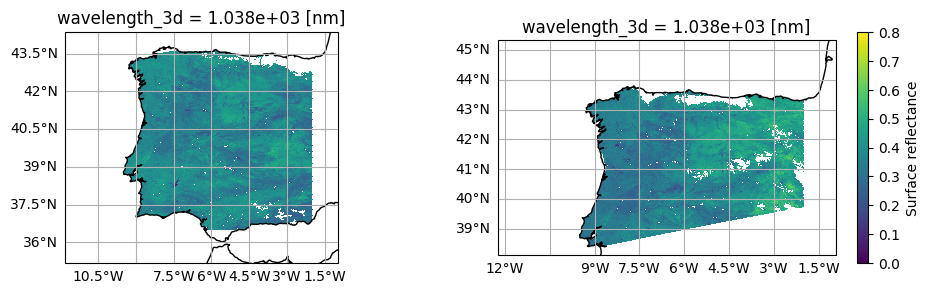

In [4]:
# Plot to make sure everything worked
fig, ax = plt.subplots(1, 2, subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(12,3))
ax[0].coastlines()
ax[1].coastlines()
ax[0].gridlines(draw_labels={"left": "y", "bottom": "x"})
ax[1].gridlines(draw_labels={"left": "y", "bottom": "x"})
pre_1.rhos[:,:,0].plot(x="longitude", y="latitude", vmin=0, vmax=0.8, ax=ax[0], add_colorbar=False)
pre_2.rhos[:,:,0].plot(x="longitude", y="latitude", vmin=0, vmax=0.8, ax=ax[1])
plt.show()

In [5]:
def grid_data(src, resolution, dst_crs="epsg:4326", resampling=Resampling.nearest):
    """
    Reproject a L2 dataset to match an input grid. Makes sure 3D variables are
        in (Z, Y, X) dimension order, and all variables have spatial dims/crs 
        assigned.
    Args:
        src - an xarray dataset or dataarray to reproject
        resolution - resolution of the output grid, in dst_crs units
        dst_crs - CRS of the output data
        resampling - resampling method (see rasterio.enums)
    Returns:
        dst - projected xr dataset
    """
    if (len(list(src.dims)) == 3) and (list(src.dims)[0] != "wavelength_3d"):
        src = src.transpose("wavelength_3d", ...)
    src = src.rio.set_spatial_dims("pixels_per_line", "number_of_lines")
    src = src.rio.write_crs("epsg:4326")

    # Calculating the default affine transform
    defaults = rasterio.warp.calculate_default_transform(
        src.rio.crs,
        dst_crs,
        src.rio.width,
        src.rio.height,
        left=np.min(src.longitude.data),#.attrs["geospatial_lon_min"],
        bottom=np.min(src.latitude.data),#attrs["geospatial_lat_min"],
        right=np.max(src.longitude.data),#.attrs["geospatial_lon_max"],
        top=np.max(src.latitude.data),#.attrs["geospatial_lat_max"],
    )
    # Aligning that transform to our desired resolution
    transform, width, height = rasterio.warp.aligned_target(*defaults, resolution)
    
    dst = src.rio.reproject(
        dst_crs=dst_crs,
        shape=(height, width),
        transform=transform,
        src_geoloc_array=(
            src["longitude"],
            src["latitude"],
        ),
        nodata=np.nan,
        resample=resampling,
    )
    dst["x"] = dst["x"].round(9)
    dst["y"] = dst["y"].round(9)
    
    return dst.rename({"x":"longitude", "y":"latitude"})

In [6]:
# Project first prefire granule to get grid
#dst = utils.reproject_3d(pre_1["rhos"])
#crs = dst.rio.crs
#shape = dst.rio.shape
#transform = dst.rio.transform()

# Project 2nd prefire
#pre2_dst = utils.grid_match_3d(pre_2["rhos"], 
#                              crs=crs,
#                              dst_shape=shape,
#                              transform=transform)

# Grid the data
resolution = (0.015, 0.015)
dst = grid_data(pre_1, resolution)
pre2_dst = grid_data(pre_2, resolution)

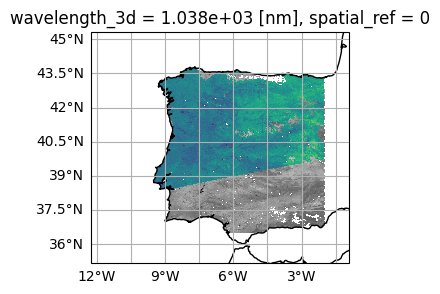

In [7]:
# Overlay to make sure datasets match
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(12,3))
ax.coastlines()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
dst.rhos[0,:,:].plot(x="longitude", y="latitude", vmin=0, vmax=0.8, ax=ax, cmap="Greys_r", add_colorbar=False)
pre2_dst.rhos[0,:,:].plot(x="longitude", y="latitude", vmin=0, vmax=0.8, ax=ax, add_colorbar=False)
plt.show()

In [9]:
post_1, post_2,post_2_2 = utils.open_nc(paths[2]), utils.open_nc(paths[3]),utils.open_nc(paths[4])

/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


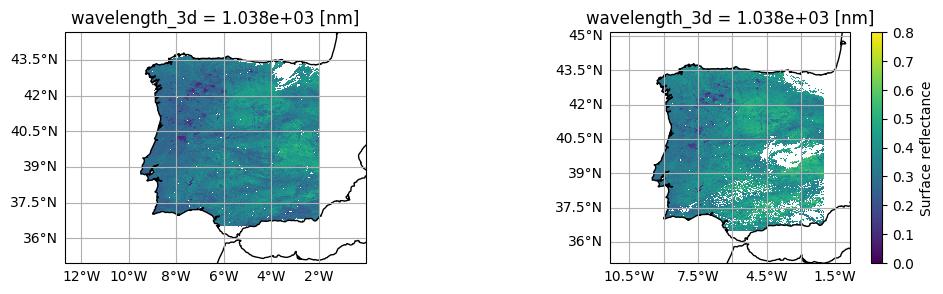

In [10]:
# Repeat the process with post-fire days
#results = earthaccess.search_data(
#    short_name="PACE_OCI_L2_SFREFL",
#    temporal=tspan_post,
#    bounding_box=scene,
#    cloud_cover=(0, 75)
#)

#results = [results[0], results[-1]]
#if in_the_cloud:
#    paths = earthaccess.open(results)
#else:
#    paths = earthaccess.download(results, local_path="local_data")

# Open, mask, pre-process
#post_1, post_2 = utils.open_nc(paths[0]), utils.open_nc(paths[1])

# Subset to necessary bands only for speed
post_1 = post_1.sel({"wavelength_3d":[1038, 2131]}, method="nearest")
post_2 = post_2.sel({"wavelength_3d":[1038, 2131]}, method="nearest")
post_2_2 = post_2_2.sel({"wavelength_3d":[1038, 2131]}, method="nearest")

# Subset and Mask 
post_1, post_2, post_2_2 = utils.subset(post_1, scene), utils.subset(post_2, scene), utils.subset(post_2_2, scene)
post_1, post_2, post_2_2 = utils.mask_ds(post_1), utils.mask_ds(post_2), utils.mask_ds(post_2_2)
post_1, post_2, post_2_2 = utils.mask_ds(post_1, "LAND", mask_reverse=True), utils.mask_ds(post_2, "LAND", mask_reverse=True), utils.mask_ds(post_2_2, "LAND", mask_reverse=True)

# Plot to make sure everything worked
fig, ax = plt.subplots(1, 2, subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(12,3))
ax[0].coastlines()
ax[1].coastlines()
ax[0].gridlines(draw_labels={"left": "y", "bottom": "x"})
ax[1].gridlines(draw_labels={"left": "y", "bottom": "x"})
post_1.rhos[:,:,0].plot(x="longitude", y="latitude", vmin=0, vmax=0.8, ax=ax[0], add_colorbar=False)
post_2_2.rhos[:,:,0].plot(x="longitude", y="latitude", vmin=0, vmax=0.8, ax=ax[1], add_colorbar=False)
post_2.rhos[:,:,0].plot(x="longitude", y="latitude", vmin=0, vmax=0.8, ax=ax[1])
plt.show()

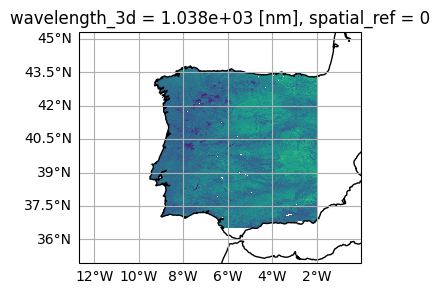

In [11]:
# Project post fire granules onto prefire grid
#post1_dst = utils.grid_match_3d(post_1["rhos"], crs=crs, dst_shape=shape, transform=transform)
#post2_dst = utils.grid_match_3d(post_2["rhos"], crs=crs, dst_shape=shape, transform=transform)

post1_dst = grid_data(post_1, resolution)
post2_dst = grid_data(post_2, resolution)
post2_2_dst = grid_data(post_2_2, resolution)


# Overlay all to make sure datasets match
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(12,3))
ax.coastlines()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
dst.rhos[0,:,:].plot(x="longitude", y="latitude", vmin=0, vmax=0.8, ax=ax, cmap="Greys_r", add_colorbar=False)
pre2_dst.rhos[0,:,:].plot(x="longitude", y="latitude", vmin=0, vmax=0.8, ax=ax, add_colorbar=False)
post2_dst.rhos[0,:,:].plot(x="longitude", y="latitude", vmin=0, vmax=0.8, ax=ax, add_colorbar=False)
post2_2_dst.rhos[0,:,:].plot(x="longitude", y="latitude", vmin=0, vmax=0.8, ax=ax, add_colorbar=False)
post1_dst.rhos[0,:,:].plot(x="longitude", y="latitude", vmin=0, vmax=0.8, ax=ax, add_colorbar=False)
plt.show()

In [12]:
# Average NIR and SWIR over time 
pre_all = xr.combine_nested([dst, pre2_dst],concat_dim="time")
pre_mean_nir = pre_all.sel({"wavelength_3d":1038}, method="nearest").mean("time")
pre_mean_swir = pre_all.sel({"wavelength_3d":2131}, method="nearest").mean("time")

post_all = xr.combine_nested([post1_dst, post2_dst, post2_2_dst],concat_dim="time")
post_mean_nir = post_all.sel({"wavelength_3d":1038}, method="nearest").mean("time")
post_mean_swir = post_all.sel({"wavelength_3d":2131}, method="nearest").mean("time")

# Calculate NBR
pre_nbr = calc_nbr(nir=pre_mean_nir, swir=pre_mean_swir)
post_nbr = calc_nbr(nir=post_mean_nir, swir=post_mean_swir)

In [13]:
post_nbr

<xarray.Dataset> Size: 7MB
Dimensions:      (longitude: 844, latitude: 683)
Coordinates:
  * longitude    (longitude) float64 7kB -12.67 -12.65 ... -0.0375 -0.0225
  * latitude     (latitude) float64 5kB 34.94 34.96 34.97 ... 45.14 45.16 45.17
    spatial_ref  int64 8B 0
Data variables:
    nbr          (latitude, longitude) float32 2MB nan nan nan ... nan nan nan
    l2_flags     (latitude, longitude) float64 5MB nan nan nan ... nan nan nan

In [14]:
# Calculate dNBR
dnbr = pre_nbr - post_nbr
dnbr = dnbr.rename({"nbr":"dNBR"})

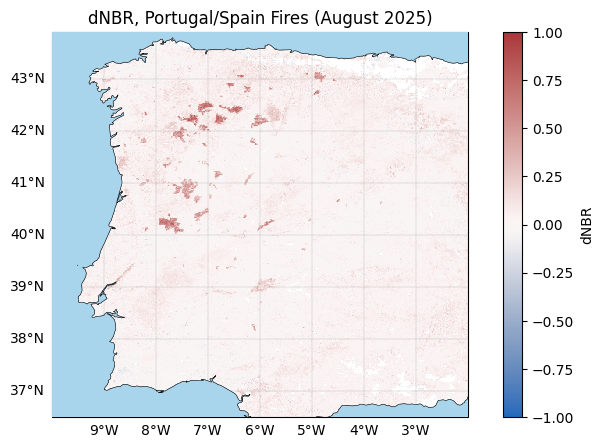

In [15]:
fig, ax = plt.subplots(figsize=(9, 5), 
                       subplot_kw={"projection": ccrs.PlateCarree()})
dnbr.dNBR.plot(vmin=-1, vmax=1, cmap=sns.color_palette("vlag", as_cmap=True))
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.25)
ax.coastlines(linewidth=0.5)
ax.add_feature(water_mask, zorder=100, facecolor='#a8d4ec', 
               edgecolor='k', linewidth=0.25)
ax.set_extent(plot_ext, crs=ccrs.PlateCarree())                               # Just to start, likely zoom in as below 
#ax.set_extent((-119, -117.75, 33.6, 34.5), crs=ccrs.PlateCarree())
ax.set_title(title)
plt.show()

In [16]:
# Could classify as well or export to file for plotting in GIS
sr_dst_name = "data/ibr_fires_aug25_dnbr_whole.tif"
profile = {
    "driver": "COG",
    "width": dnbr["dNBR"].shape[1],
    "height": dnbr["dNBR"].shape[0],
    "count": 1,
    "crs": dnbr.rio.crs,
    "dtype": dnbr["dNBR"].dtype,
    "transform": dnbr.rio.transform(),
    "compress": "lzw",
    "nodata": np.nan,
    "interleave":"BAND",
    "tiled":"YES",
    "blockxsize": "512", "blockysize": "512",
}
dnbr["dNBR"].rio.to_raster(sr_dst_name, **profile)

In [17]:
pre_1, pre_2 = utils.open_nc(paths[0]), utils.open_nc(paths[1])
post_1, post_2,post_2_2 = utils.open_nc(paths[2]), utils.open_nc(paths[3]),utils.open_nc(paths[4])

# Subset and Mask 
pre_1, pre_2 = utils.subset(pre_1, scene), utils.subset(pre_2, scene)
pre_1, pre_2 = utils.mask_ds(pre_1), utils.mask_ds(pre_2)
pre_1, pre_2 = utils.mask_ds(pre_1, "LAND", mask_reverse=True), utils.mask_ds(pre_2, "LAND", mask_reverse=True)
post_1, post_2, post_2_2 = utils.subset(post_1, scene), utils.subset(post_2, scene), utils.subset(post_2_2, scene)
post_1, post_2, post_2_2 = utils.mask_ds(post_1), utils.mask_ds(post_2), utils.mask_ds(post_2_2)
post_1, post_2, post_2_2 = utils.mask_ds(post_1, "LAND", mask_reverse=True), utils.mask_ds(post_2, "LAND", mask_reverse=True), utils.mask_ds(post_2_2, "LAND", mask_reverse=True)

resolution = (0.015, 0.015)
pre1_dst = grid_data(pre_1, resolution)
pre2_dst = grid_data(pre_2, resolution)
post1_dst = grid_data(post_1, resolution)
post2_dst = grid_data(post_2, resolution)
post2_2_dst = grid_data(post_2_2, resolution)

pre_all = xr.combine_nested([pre1_dst, pre2_dst],concat_dim="time")
pre_mean = pre_all.mean("time")
post_all = xr.combine_nested([post1_dst, post2_dst, post2_2_dst],concat_dim="time")
post_mean = post_all.mean("time")
post_mean

/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid va

<xarray.Dataset> Size: 286MB
Dimensions:        (wavelength_3d: 122, latitude: 683, longitude: 844)
Coordinates:
  * longitude      (longitude) float64 7kB -12.67 -12.65 ... -0.0375 -0.0225
  * latitude       (latitude) float64 5kB 34.94 34.96 34.97 ... 45.16 45.17
  * wavelength_3d  (wavelength_3d) float64 976B 346.0 351.0 ... 2.258e+03
    spatial_ref    int64 8B 0
Data variables:
    rhos           (wavelength_3d, latitude, longitude) float32 281MB nan ......
    l2_flags       (latitude, longitude) float64 5MB nan nan nan ... nan nan nan

In [18]:
def calc_cire(r800, r705):
    """
    Calculates Normalized Burn Ratio given NIR and SWIR datasets
    Args:
        nir, swir - datasets of NIR and SWIR info
    Returns:
        nbr - NBR dataset
    """
    cire = (r800/r705 - 1)
    cire = cire.rename({"rhos":"CIRE"})
    return cire

pre_cire = calc_cire(pre_mean.sel({"wavelength_3d":800}, method="nearest"), 
                     pre_mean.sel({"wavelength_3d":705}, method="nearest"))
post_cire = calc_cire(post_mean.sel({"wavelength_3d":800}, method="nearest"), 
                      post_mean.sel({"wavelength_3d":705}, method="nearest"))

In [21]:
pre_norm = pre_cire.CIRE/np.max(pre_cire.CIRE)
post_norm = post_cire.CIRE/np.max(post_cire.CIRE)

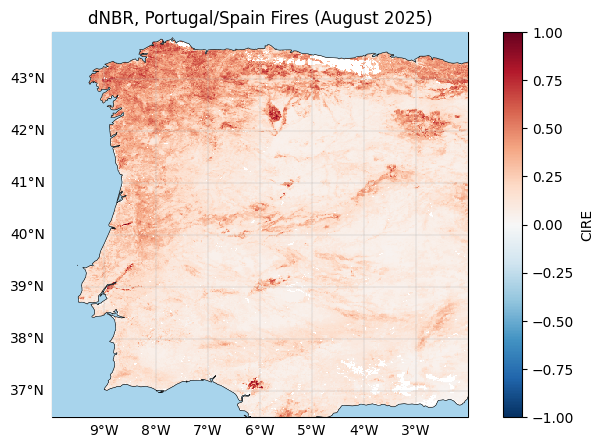

In [23]:
fig, ax = plt.subplots(figsize=(9, 5), 
                       subplot_kw={"projection": ccrs.PlateCarree()})
pre_norm.plot()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.25)
ax.coastlines(linewidth=0.5)
ax.add_feature(water_mask, zorder=100, facecolor='#a8d4ec', 
               edgecolor='k', linewidth=0.25)
ax.set_extent(plot_ext, crs=ccrs.PlateCarree())                               # Just to start, likely zoom in as below 
#ax.set_extent((-119, -117.75, 33.6, 34.5), crs=ccrs.PlateCarree())
ax.set_title(title)
plt.show()

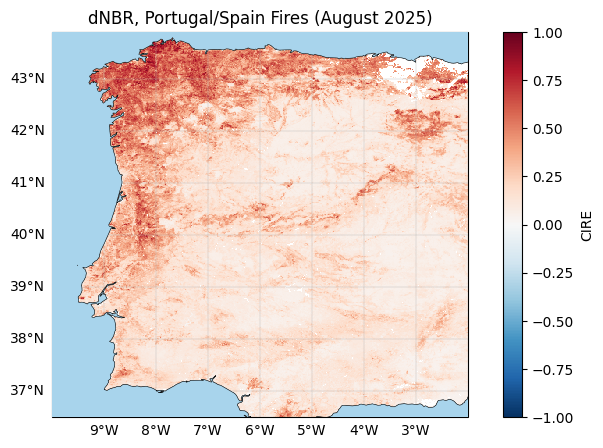

In [24]:
fig, ax = plt.subplots(figsize=(9, 5), 
                       subplot_kw={"projection": ccrs.PlateCarree()})
post_norm.plot()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.25)
ax.coastlines(linewidth=0.5)
ax.add_feature(water_mask, zorder=100, facecolor='#a8d4ec', 
               edgecolor='k', linewidth=0.25)
ax.set_extent(plot_ext, crs=ccrs.PlateCarree())                               # Just to start, likely zoom in as below 
#ax.set_extent((-119, -117.75, 33.6, 34.5), crs=ccrs.PlateCarree())
ax.set_title(title)
plt.show()

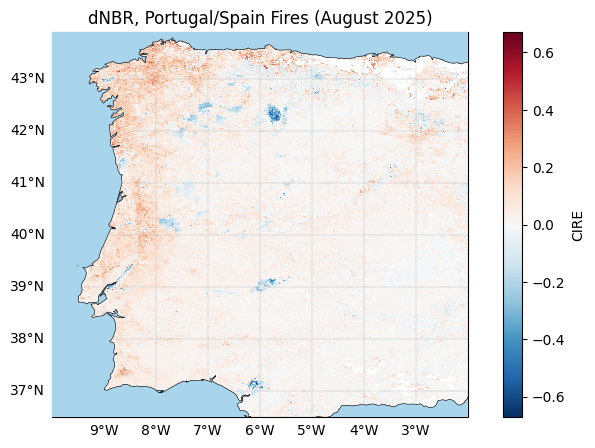

In [26]:
cire_diff = post_norm - pre_norm
fig, ax = plt.subplots(figsize=(9, 5), 
                       subplot_kw={"projection": ccrs.PlateCarree()})
cire_diff.plot()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.25)
ax.coastlines(linewidth=0.5)
ax.add_feature(water_mask, zorder=100, facecolor='#a8d4ec', 
               edgecolor='k', linewidth=0.25)
ax.set_extent(plot_ext, crs=ccrs.PlateCarree())                               # Just to start, likely zoom in as below 
#ax.set_extent((-119, -117.75, 33.6, 34.5), crs=ccrs.PlateCarree())
ax.set_title(title)
plt.show()

In [27]:
# Could classify as well or export to file for plotting in GIS
sr_dst_name = "data/ibr_cire_pre.tif"
profile = {
    "driver": "COG",
    "width": pre_cire["CIRE"].shape[1],
    "height": pre_cire["CIRE"].shape[0],
    "count": 1,
    "crs": pre_cire.rio.crs,
    "dtype": pre_cire["CIRE"].dtype,
    "transform": pre_cire.rio.transform(),
    "compress": "lzw",
    "nodata": np.nan,
    "interleave":"BAND",
    "tiled":"YES",
    "blockxsize": "512", "blockysize": "512",
}
pre_cire["CIRE"].rio.to_raster(sr_dst_name, **profile)

sr_dst_name = "data/ibr_cire_post.tif"
profile = {
    "driver": "COG",
    "width": post_cire["CIRE"].shape[1],
    "height": post_cire["CIRE"].shape[0],
    "count": 1,
    "crs": post_cire.rio.crs,
    "dtype": post_cire["CIRE"].dtype,
    "transform": post_cire.rio.transform(),
    "compress": "lzw",
    "nodata": np.nan,
    "interleave":"BAND",
    "tiled":"YES",
    "blockxsize": "512", "blockysize": "512",
}
post_cire["CIRE"].rio.to_raster(sr_dst_name, **profile)

sr_dst_name = "data/ibr_cire_norm_diff.tif"
profile = {
    "driver": "COG",
    "width": cire_diff.shape[1],
    "height": cire_diff.shape[0],
    "count": 1,
    "crs": cire_diff.rio.crs,
    "dtype": cire_diff.dtype,
    "transform": cire_diff.rio.transform(),
    "compress": "lzw",
    "nodata": np.nan,
    "interleave":"BAND",
    "tiled":"YES",
    "blockxsize": "512", "blockysize": "512",
}
cire_diff.rio.to_raster(sr_dst_name, **profile)